In [7]:
import os
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, Callback

In [8]:
class DoubleConv(nn.Module):
    """Two 3x3 unpadded convolutions, each followed by BN and ReLU [cite: 82]"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=0),
            nn.BatchNorm2d(out_channels), # Added for stability
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=0),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

In [9]:
class UNetV3(pl.LightningModule):
    def __init__(self, in_channels=3, out_classes=1, lr=3e-4):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        # Encoder (Contracting Path) [cite: 80, 81]
        self.down1, self.down2 = DoubleConv(in_channels, 64), DoubleConv(64, 128)
        self.down3, self.down4 = DoubleConv(128, 256), DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) 
        
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        
        # Decoder (Expanding Path) [cite: 80, 84]
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)
        
        self.final_conv = nn.Conv2d(64, out_classes, kernel_size=1) 
        self.bce_loss = nn.BCEWithLogitsLoss()

    def crop_and_concat(self, upsampled, bypass):
        """Cropping bypass to match upsampled size [cite: 85]"""
        diff = (bypass.size(2) - upsampled.size(2)) // 2
        bypass = bypass[:, :, diff:diff+upsampled.size(2), diff:diff+upsampled.size(3)]
        return torch.cat((bypass, upsampled), dim=1)

    def forward(self, x):
        s1 = self.down1(x); p1 = self.pool(s1)
        s2 = self.down2(p1); p2 = self.pool(s2)
        s3 = self.down3(p2); p3 = self.pool(s3)
        s4 = self.down4(p3); p4 = self.pool(s4)
        bn = self.bottleneck(p4)
        d4 = self.conv4(self.crop_and_concat(self.up4(bn), s4))
        d3 = self.conv3(self.crop_and_concat(self.up3(d4), s3))
        d2 = self.conv2(self.crop_and_concat(self.up2(d3), s2))
        d1 = self.conv1(self.crop_and_concat(self.up1(d2), s1))
        return self.final_conv(d1)

    # --- Improved Metrics & Loss Logic ---
    def soft_dice_loss(self, pred, target):
        pred = torch.sigmoid(pred)
        smooth = 1e-6
        intersection = (pred * target).sum()
        return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    def calculate_iou(self, pred, target):
        pred = (torch.sigmoid(pred) > 0.5).float()
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum() - intersection
        return (intersection + 1e-7) / (union + 1e-7)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        y = self.match_size(y, y_hat)
        loss = self.bce_loss(y_hat, y) + self.soft_dice_loss(y_hat, y) # Hybrid Loss
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        y = self.match_size(y, y_hat)
        v_loss = self.bce_loss(y_hat, y) + self.soft_dice_loss(y_hat, y)
        dice = (2. * ((torch.sigmoid(y_hat)>0.5)*y).sum() + 1e-7) / ((torch.sigmoid(y_hat)>0.5).sum() + y.sum() + 1e-7)
        iou = self.calculate_iou(y_hat, y)
        self.log_dict({"val_loss": v_loss, "val_dice": dice, "val_iou": iou}, prog_bar=True)

    def match_size(self, target, ref):
        """Matches GT size to output size [cite: 64, 91]"""
        d = (target.size(2) - ref.size(2)) // 2
        return target[:, :, d:d+ref.size(2), d:d+ref.size(3)]

    def configure_optimizers(self): return torch.optim.Adam(self.parameters(), lr=self.lr)

In [10]:
class BrainDataset(Dataset):
    def __init__(self, imgs, masks): self.imgs, self.masks = imgs, masks
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        # Resize to paper-specified 572x572 [cite: 27]
        img = cv2.resize(cv2.cvtColor(cv2.imread(self.imgs[i]), cv2.COLOR_BGR2RGB), (572, 572))
        mask = cv2.resize(cv2.imread(self.masks[i], 0), (572, 572))
        return (torch.from_numpy(img).permute(2,0,1).float()/255., 
                torch.from_numpy(mask).unsqueeze(0).float()/255.)

In [11]:
class MetricsLogger(Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        with open("v3_comprehensive_log.txt", "a") as f:
            f.write(f"Epoch {trainer.current_epoch}: Val_Loss {m.get('val_loss', 0):.4f} | "
                    f"Val_Dice {m.get('val_dice', 0):.4f} | Val_IoU {m.get('val_iou', 0):.4f}\n")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type              | Params | Mode  | FLOPs
------------------------------------------------------------------
0  | down1      | DoubleConv        | 39.0 K | train | 0    
1  | down2      | DoubleConv        | 221 K  | train | 0    
2  | down3      | DoubleConv        | 886 K  | train | 0    
3  | down4      | DoubleConv        | 3.5 M  | train | 0    
4  | pool       | MaxPool2d         | 0      | train | 0    
5  | bottleneck | DoubleConv        | 14.2 M | train | 0    
6  | up4        | ConvTranspose2d   | 2.1 M  | train | 0    
7  | conv4      | DoubleConv        | 7.1 M  | train | 0    
8  | up3        | ConvTranspose

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


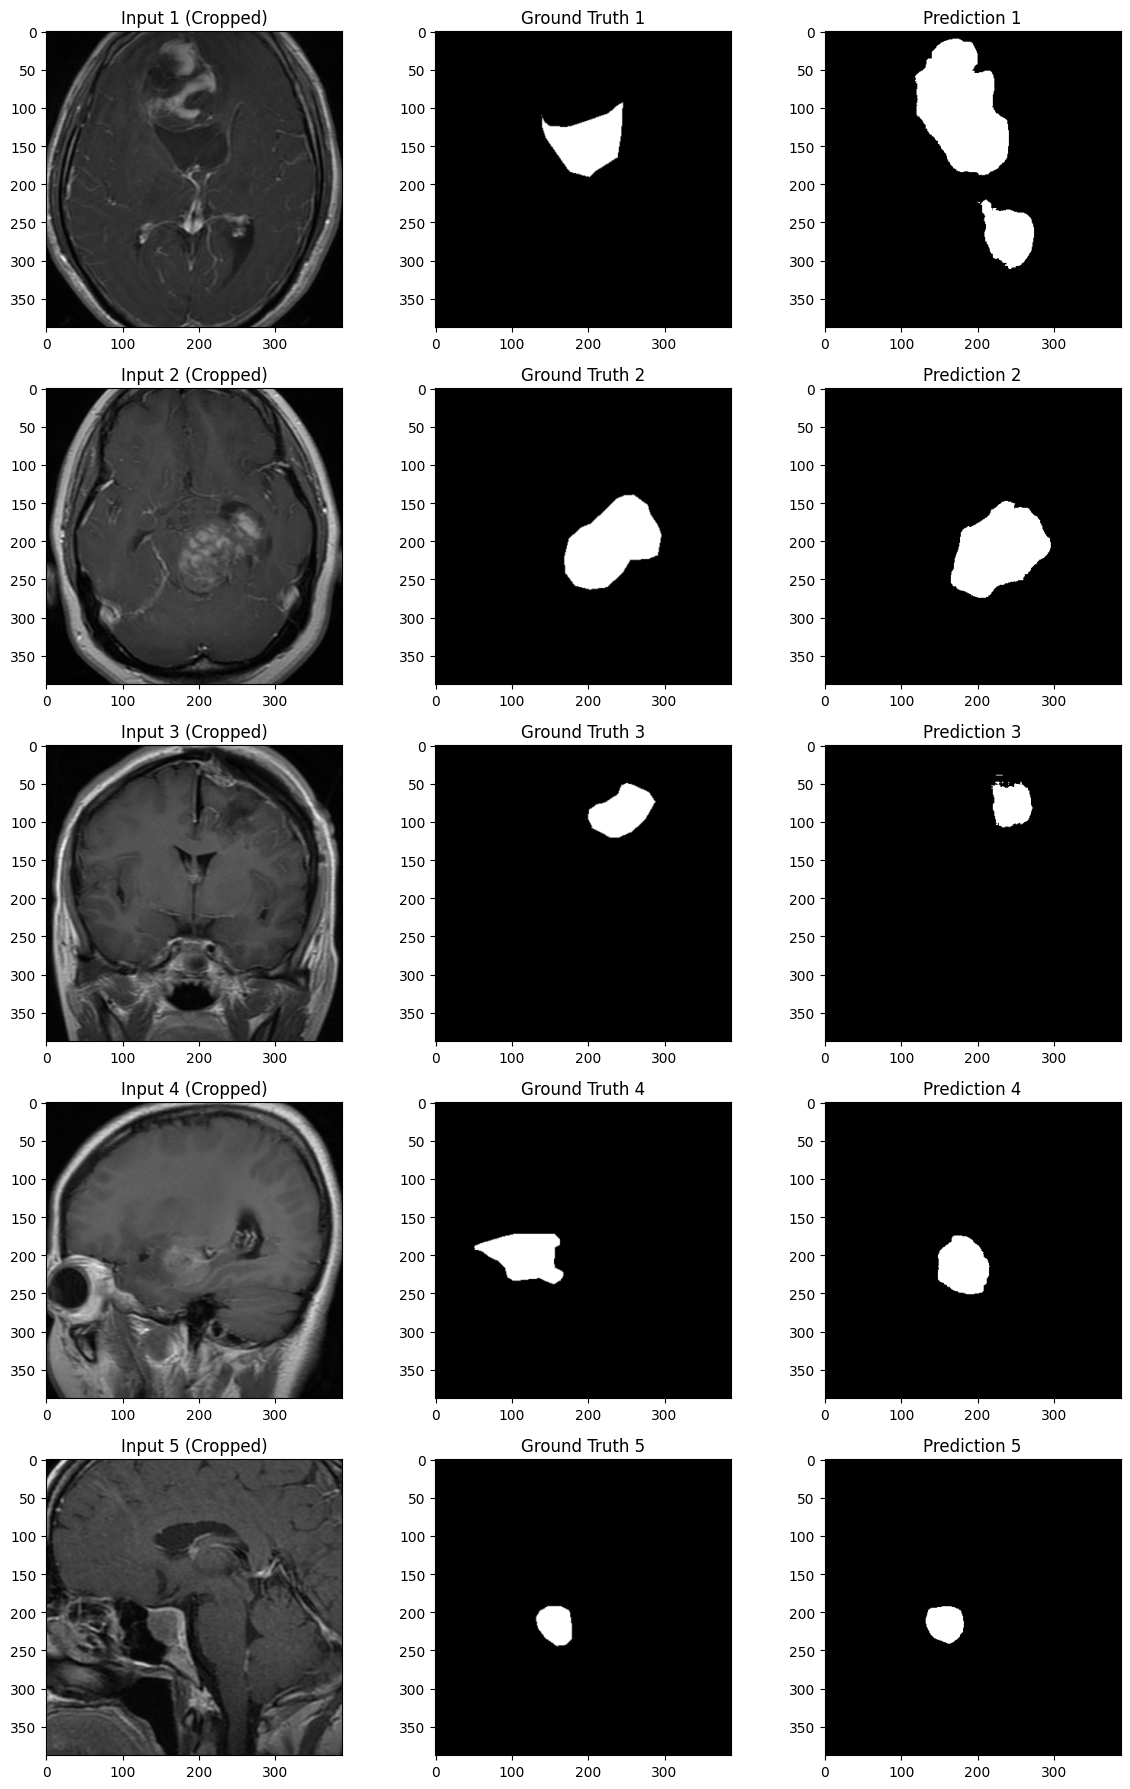

Training completed. Metrics logged in v3_comprehensive_log.txt. Best model saved.


In [12]:
def run_v3():
    # PATHS (Dataset folder structure onusarey change koro)
    img_list = sorted(glob("dataset/images/*.png"))
    mask_list = sorted(glob("dataset/masks/*.png"))
    
    ds = BrainDataset(img_list, mask_list)
    train_size = int(0.8 * len(ds))
    val_size = int(0.1 * len(ds))
    test_size = len(ds) - train_size - val_size
    train, val, test = random_split(ds, [train_size, val_size, test_size])
    
    model = UNetV3()
    checkpoint = ModelCheckpoint(monitor="val_dice", mode="max", save_top_k=1, filename="best_v3_unet")
    trainer = pl.Trainer(max_epochs=20, callbacks=[checkpoint, MetricsLogger()], accelerator="auto")
    
    # Train
    trainer.fit(model, DataLoader(train, batch_size=4, shuffle=True), DataLoader(val, batch_size=4))

    # Test Visualization (5 Unique Images)
    best_model = UNetV3.load_from_checkpoint(checkpoint.best_model_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    best_model.to(device).eval()
    
    fig, axes = plt.subplots(5, 3, figsize=(12, 18))
    for i in range(5):
        img, mask = test[i]
        input_t = img.unsqueeze(0).to(device)
        with torch.no_grad():
            pred = torch.sigmoid(best_model(input_t)) > 0.5
        
        # CPU-te niye plotting and cropping to match unpadded output size [cite: 91]
        img_c = best_model.match_size(img.unsqueeze(0), pred.cpu()).squeeze().permute(1,2,0).numpy()
        mask_c = best_model.match_size(mask.unsqueeze(0), pred.cpu()).squeeze().numpy()
        pred_c = pred.squeeze().cpu().numpy()
        
        axes[i,0].imshow(img_c); axes[i,0].set_title(f"Input {i+1} (Cropped)")
        axes[i,1].imshow(mask_c, cmap='gray'); axes[i,1].set_title(f"Ground Truth {i+1}")
        axes[i,2].imshow(pred_c, cmap='gray'); axes[i,2].set_title(f"Prediction {i+1}")
        
    plt.tight_layout()
    plt.savefig("v3_final_report.png")
    plt.show()
    print(f"Training completed. Metrics logged in v3_comprehensive_log.txt. Best model saved.")

if __name__ == "__main__":
    run_v3()